# B8 – Dynamic Multipliers & Asymmetric IRF

Based on NARDL from B4.
- **Dynamic multipliers** (Shin et al. 2014): cumulative response of Y to unit shock in `ln_RER_pos` / `ln_RER_neg`
- **Asymmetric IRF**: compare pos vs neg path → detect asymmetry
- **Bootstrap 95% CI** (parametric)

In [1]:
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.ardl import ARDL
print('Libraries loaded OK')

Libraries loaded OK


## 1. Re-estimate NARDL (from B4)

In [2]:
data_file = '../data/processed/data_processed.csv'
data_processed = pd.read_csv(data_file)

models = {
    'Model_2_EX': {
        'dep_var'  : 'ln_EX',
        'exog_vars': ['ln_RER_pos','ln_RER_neg','ln_FDI','IPI_VN',
                      'IPI_World_GR_diff','ln_M2_diff','ln_WTI','COVID'],
        'lag_dep'  : 6,
        'lag_exog' : [3, 1, 6, 6, 5, 2, 0]
    },
    'Model_3_IM': {
        'dep_var'  : 'ln_IM',
        'exog_vars': ['ln_RER_pos','ln_RER_neg','ln_FDI','IPI_VN',
                      'IPI_World_GR_diff','ln_M2_diff','ln_WTI','COVID'],
        'lag_dep'  : 3,
        'lag_exog' : [3, 1, 2, 2, 4, 3, 0]
    }
}

OUTPUT_DIR = '../results/dynamic_multiplier'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def create_lags(df, var_list, lag_list):
    df_out = df.copy()
    for var, lag in zip(var_list, lag_list):
        if lag > 0:
            for l in range(1, lag + 1):
                df_out[f'{var}_L{l}'] = df_out[var].shift(l)
    return df_out

fitted_models = {}
for model_name, spec in models.items():
    dep   = spec['dep_var']
    exogs = [v for v in spec['exog_vars'] if v in data_processed.columns]
    df_m  = data_processed[[dep] + exogs].dropna()
    df_m  = create_lags(df_m, exogs, spec['lag_exog'])
    df_m  = df_m.dropna()
    exog_lag = [c for c in df_m.columns if c != dep]
    ardl = ARDL(df_m[dep], lags=spec['lag_dep'], exog=df_m[exog_lag], trend='c')
    res  = ardl.fit()
    fitted_models[model_name] = {'res': res, 'dep': dep, 'spec': spec, 'df_m': df_m, 'exogs': exogs}
    ecm = res.params.get(f'{dep}.L1', np.nan)
    print(f'{model_name}: ECM(-1)={ecm:.4f}  n={len(df_m)}')
print('Models fitted OK')

Model_2_EX: ECM(-1)=0.3330  n=125
Model_3_IM: ECM(-1)=0.2233  n=127
Models fitted OK


## 2. Dynamic Multiplier Engine

**Method (Shin et al. 2014, eq.18-19):**

$$m_h^\pm = \sum_{j=0}^{h}\frac{\partial y_{t+j}}{\partial x_t^\pm}, \quad M_h^\pm = \sum_{j=0}^{h} m_j^\pm$$

Computed via AR transfer function: $\phi_h$ = IRF of AR polynomial, then convolve with impact coefficients $b^\pm$.

In [3]:
def compute_dynamic_multipliers(res, dep,
                                   pos_var='ln_RER_pos', neg_var='ln_RER_neg',
                                   H=24, n_boot=500, alpha=0.05, seed=42):
    rng    = np.random.default_rng(seed)
    params = res.params

    # --- 1. AR lags: a_1..a_p --------------------------------------------------
    ar_lags = sorted(
        [(int(k.split('.L')[1]), float(v))
         for k, v in params.items()
         if k.startswith(dep + '.L')],
        key=lambda x: x[0]
    )
    p = max((l for l, _ in ar_lags), default=0)
    a = np.zeros(p + 1)
    for lag, coef in ar_lags:
        a[lag] = coef

    # --- 2. Impact coefficients b_0..b_q for pos/neg --------------------------
    def get_b(var_name, par):
        b = {}
        for k, v in par.items():
            if k == var_name or k == f'{var_name}.L0':
                b[0] = float(v)
            if var_name + '_L' in k:
                try:
                    tail     = k[k.index(var_name + '_L') + len(var_name + '_L'):]
                    lag_num  = int(tail.split('.')[0].split('_')[0])
                    b[lag_num] = float(v)
                except (ValueError, IndexError):
                    pass
        if not b:
            return np.zeros(1)
        q   = max(b.keys())
        arr = np.zeros(q + 1)
        for lag, coef in b.items():
            arr[lag] = coef
        return arr

    b_pos = get_b(pos_var, params)
    b_neg = get_b(neg_var, params)

    # --- 3. AR impulse response phi_h -----------------------------------------
    def ar_irf(a_vec, H):
        phi = np.zeros(H + 1); phi[0] = 1.0
        for h in range(1, H + 1):
            for j in range(1, min(h, len(a_vec) - 1) + 1):
                phi[h] += a_vec[j] * phi[h - j]
        return phi

    phi = ar_irf(a, H)

    # --- 4. Period-by-period multiplier (causal convolution) ------------------
    def dyn_mult(b, phi, H):
        q = len(b) - 1; m = np.zeros(H + 1)
        for h in range(H + 1):
            for j in range(min(h, q) + 1):
                m[h] += phi[h - j] * b[j]
        return m

    m_pos = dyn_mult(b_pos, phi, H)
    m_neg = dyn_mult(b_neg, phi, H)

    # --- 5. Cumulative multipliers -------------------------------------------
    cum_pos  = np.cumsum(m_pos)
    cum_neg  = np.cumsum(m_neg)
    cum_diff = cum_pos - cum_neg

    # --- 6. Parametric bootstrap CI ------------------------------------------
    boot_pos  = np.zeros((n_boot, H + 1))
    boot_neg  = np.zeros((n_boot, H + 1))
    boot_diff = np.zeros((n_boot, H + 1))

    try:
        cov     = res.cov_params()
        mu_vec  = res.params.values
        for bi in range(n_boot):
            c_b   = rng.multivariate_normal(mu_vec, cov)
            par_b = pd.Series(c_b, index=params.index)
            a_b   = np.zeros(p + 1)
            for lag, _ in ar_lags:
                a_b[lag] = par_b.get(f'{dep}.L{lag}', 0.0)
            phi_b        = ar_irf(a_b, H)
            cp_b         = np.cumsum(dyn_mult(get_b(pos_var, par_b), phi_b, H))
            cn_b         = np.cumsum(dyn_mult(get_b(neg_var, par_b), phi_b, H))
            boot_pos[bi] = cp_b; boot_neg[bi] = cn_b
            boot_diff[bi]= cp_b - cn_b
    except Exception:
        pass

    lo, hi = alpha / 2 * 100, (1 - alpha / 2) * 100
    return {
        'horizon' : np.arange(H + 1),
        'pos'     : cum_pos,   'neg'     : cum_neg,   'diff'    : cum_diff,
        'pos_lo'  : np.percentile(boot_pos,  lo, axis=0),
        'pos_hi'  : np.percentile(boot_pos,  hi, axis=0),
        'neg_lo'  : np.percentile(boot_neg,  lo, axis=0),
        'neg_hi'  : np.percentile(boot_neg,  hi, axis=0),
        'diff_lo' : np.percentile(boot_diff, lo, axis=0),
        'diff_hi' : np.percentile(boot_diff, hi, axis=0),
        'm_pos'   : m_pos,    'm_neg'   : m_neg,    'phi'     : phi,
    }

print('Function defined OK')

Function defined OK


In [4]:
H = 24; N_BOOT = 500
dm_results = {}
for model_name, fm in fitted_models.items():
    print(f'Computing {model_name} ...', end=' ')
    dm = compute_dynamic_multipliers(fm['res'], fm['dep'], H=H, n_boot=N_BOOT)
    dm_results[model_name] = dm
    print(f'done  |  LR m+={dm["pos"][-1]:.4f}  m-={dm["neg"][-1]:.4f}  asym={dm["diff"][-1]:.4f}')
print('All multipliers computed OK')

Computing Model_2_EX ... done  |  LR m+=-24.4157  m-=-5.4617  asym=-18.9539
Computing Model_3_IM ... done  |  LR m+=-25.0291  m-=-3.5751  asym=-21.4540
All multipliers computed OK


## 3. Main Plots – 4 Panels per Model

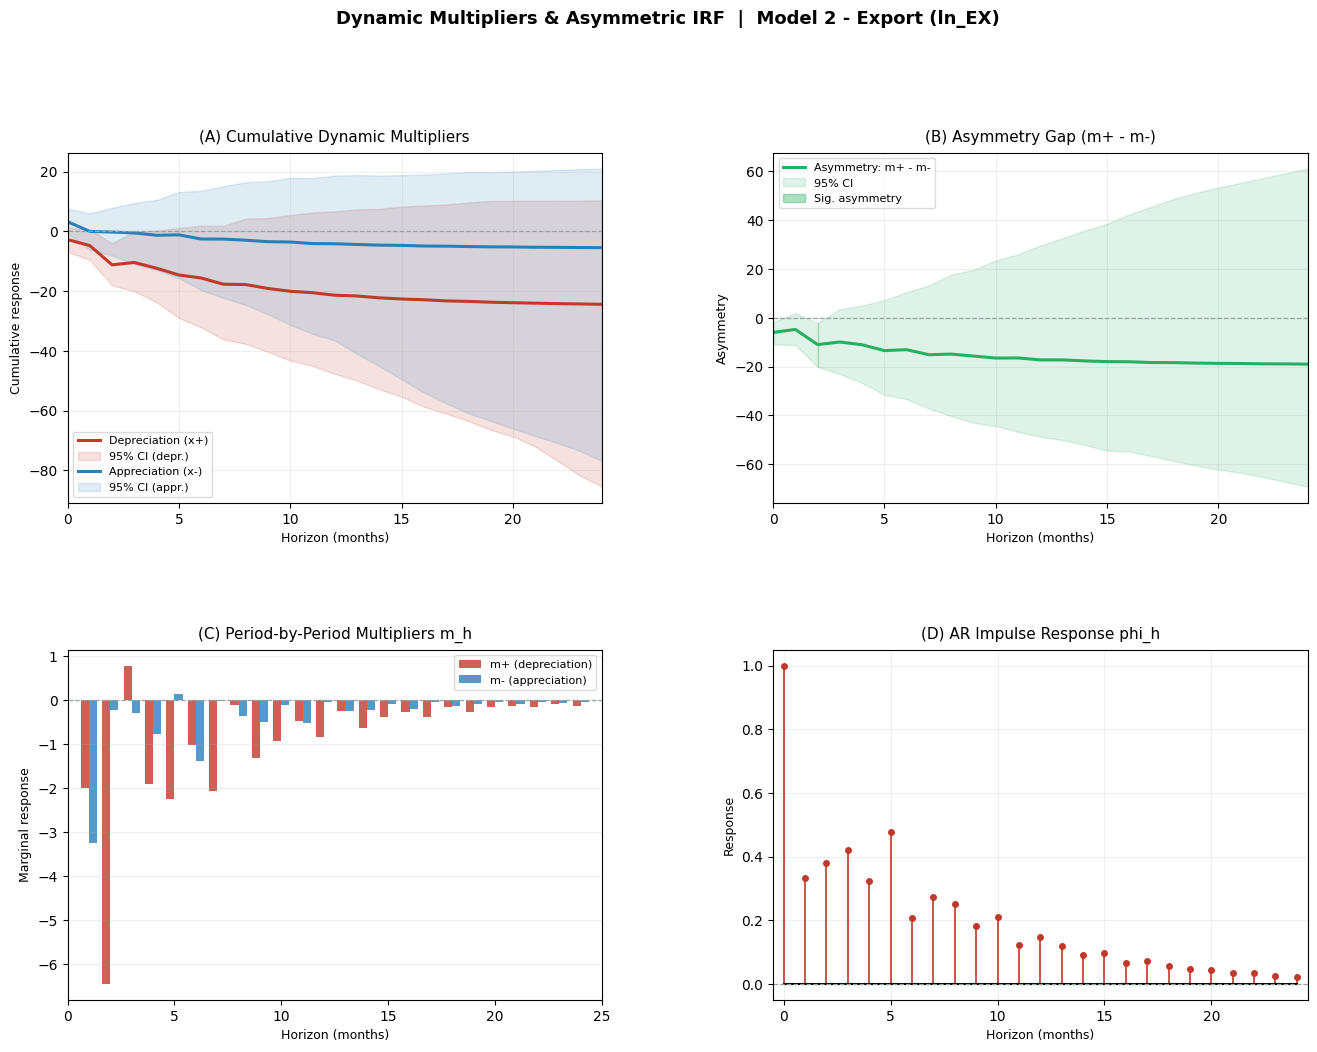

  Saved -> ../results/dynamic_multiplier\dynamic_multiplier_Model_2_EX.png


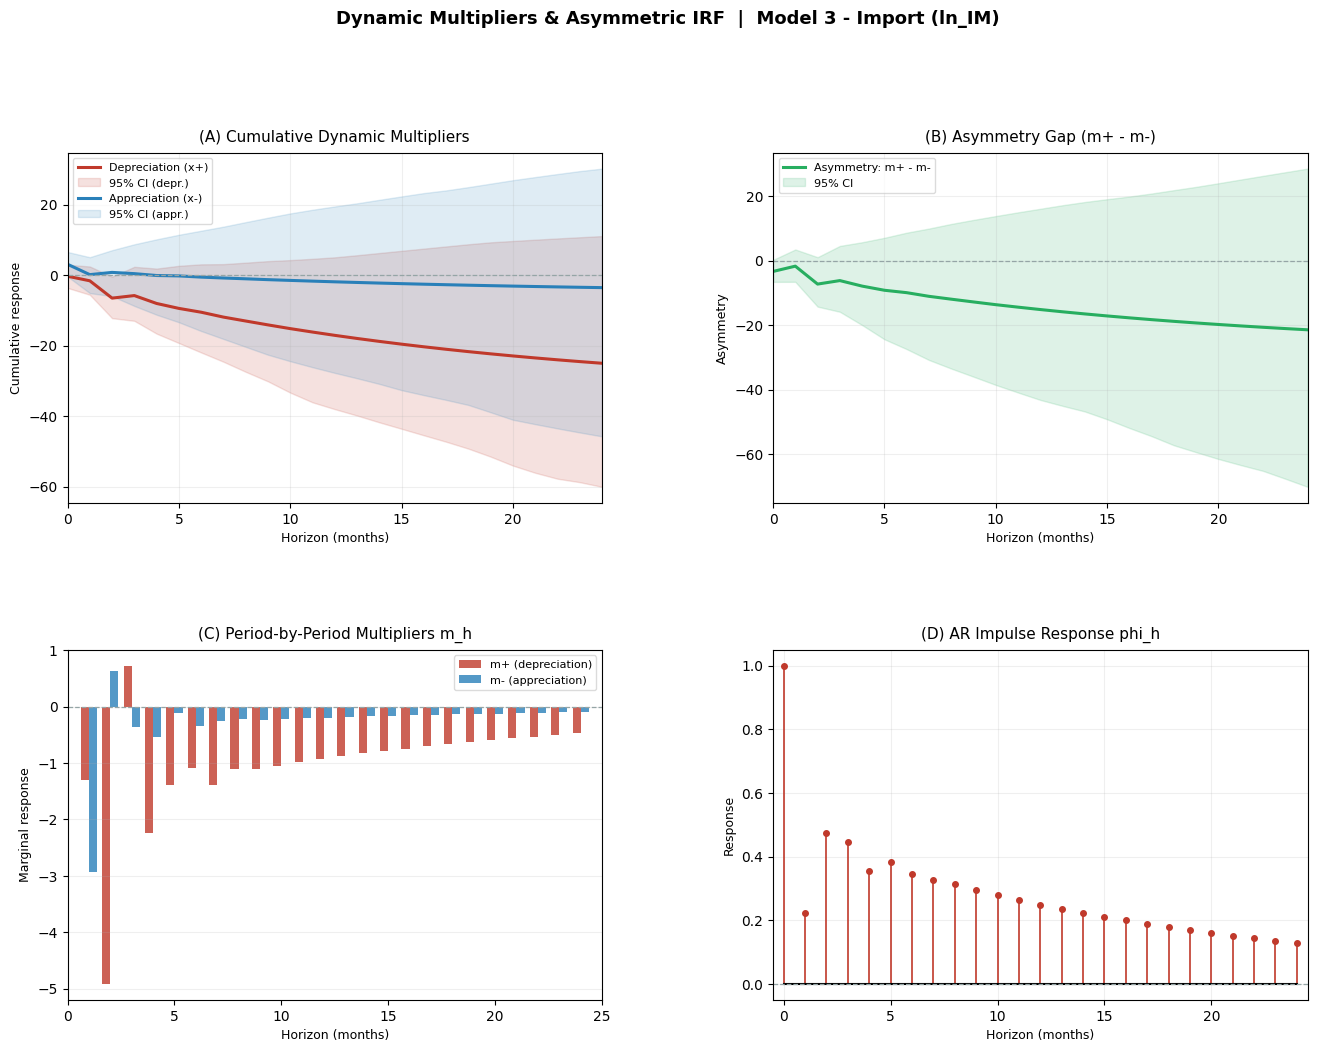

  Saved -> ../results/dynamic_multiplier\dynamic_multiplier_Model_3_IM.png


In [5]:
C_POS = '#C0392B'; C_NEG = '#2980B9'; C_DIFF = '#27AE60'; C_ZERO = '#95A5A6'

LABELS = {
    'Model_2_EX': 'Model 2 - Export (ln_EX)',
    'Model_3_IM': 'Model 3 - Import (ln_IM)'
}

for model_name, dm in dm_results.items():
    dep = fitted_models[model_name]['dep']
    h   = dm['horizon']

    fig = plt.figure(figsize=(16, 11))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
    fig.suptitle(f'Dynamic Multipliers & Asymmetric IRF  |  {LABELS[model_name]}',
                 fontsize=13, fontweight='bold', y=1.01)

    # Panel A: cumulative multipliers
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(h, dm['pos'], color=C_POS, lw=2.2, label='Depreciation (x+)')
    ax1.fill_between(h, dm['pos_lo'], dm['pos_hi'], color=C_POS, alpha=0.15, label='95% CI (depr.)')
    ax1.plot(h, dm['neg'], color=C_NEG, lw=2.2, label='Appreciation (x-)')
    ax1.fill_between(h, dm['neg_lo'], dm['neg_hi'], color=C_NEG, alpha=0.15, label='95% CI (appr.)')
    ax1.axhline(0, color=C_ZERO, lw=0.9, ls='--')
    ax1.set_title('(A) Cumulative Dynamic Multipliers', fontsize=11, pad=8)
    ax1.set_xlabel('Horizon (months)', fontsize=9); ax1.set_ylabel('Cumulative response', fontsize=9)
    ax1.legend(fontsize=8, framealpha=0.7); ax1.grid(alpha=0.2); ax1.set_xlim(0, H)

    # Panel B: asymmetry gap
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(h, dm['diff'], color=C_DIFF, lw=2.2, label='Asymmetry: m+ - m-')
    ax2.fill_between(h, dm['diff_lo'], dm['diff_hi'], color=C_DIFF, alpha=0.15, label='95% CI')
    sig_mask = (dm['diff_lo'] > 0) | (dm['diff_hi'] < 0)
    if sig_mask.any():
        ax2.fill_between(h, dm['diff_lo'], dm['diff_hi'],
                         where=sig_mask, color=C_DIFF, alpha=0.38, label='Sig. asymmetry')
    ax2.axhline(0, color=C_ZERO, lw=0.9, ls='--')
    ax2.set_title('(B) Asymmetry Gap (m+ - m-)', fontsize=11, pad=8)
    ax2.set_xlabel('Horizon (months)', fontsize=9); ax2.set_ylabel('Asymmetry', fontsize=9)
    ax2.legend(fontsize=8, framealpha=0.7); ax2.grid(alpha=0.2); ax2.set_xlim(0, H)

    # Panel C: period-by-period bars
    ax3 = fig.add_subplot(gs[1, 0])
    w = 0.38; x = h[1:]
    ax3.bar(x - w/2, dm['m_pos'][1:], width=w, color=C_POS, alpha=0.8, label='m+ (depreciation)')
    ax3.bar(x + w/2, dm['m_neg'][1:], width=w, color=C_NEG, alpha=0.8, label='m- (appreciation)')
    ax3.axhline(0, color=C_ZERO, lw=0.9, ls='--')
    ax3.set_title('(C) Period-by-Period Multipliers m_h', fontsize=11, pad=8)
    ax3.set_xlabel('Horizon (months)', fontsize=9); ax3.set_ylabel('Marginal response', fontsize=9)
    ax3.legend(fontsize=8, framealpha=0.7); ax3.grid(axis='y', alpha=0.2); ax3.set_xlim(0, H + 1)

    # Panel D: AR IRF phi
    ax4 = fig.add_subplot(gs[1, 1])
    markerline, stemlines, baseline = ax4.stem(h, dm['phi'], linefmt='-', markerfmt='o', basefmt='k-')
    plt.setp(markerline, color=C_POS, markersize=4)
    plt.setp(stemlines,  color=C_POS, lw=1.2)
    ax4.axhline(0, color=C_ZERO, lw=0.9, ls='--')
    ax4.set_title('(D) AR Impulse Response phi_h', fontsize=11, pad=8)
    ax4.set_xlabel('Horizon (months)', fontsize=9); ax4.set_ylabel('Response', fontsize=9)
    ax4.grid(alpha=0.2); ax4.set_xlim(-0.5, H + 0.5)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f'dynamic_multiplier_{model_name}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved -> {path}')

## 4. Combined: EX vs IM Side-by-Side

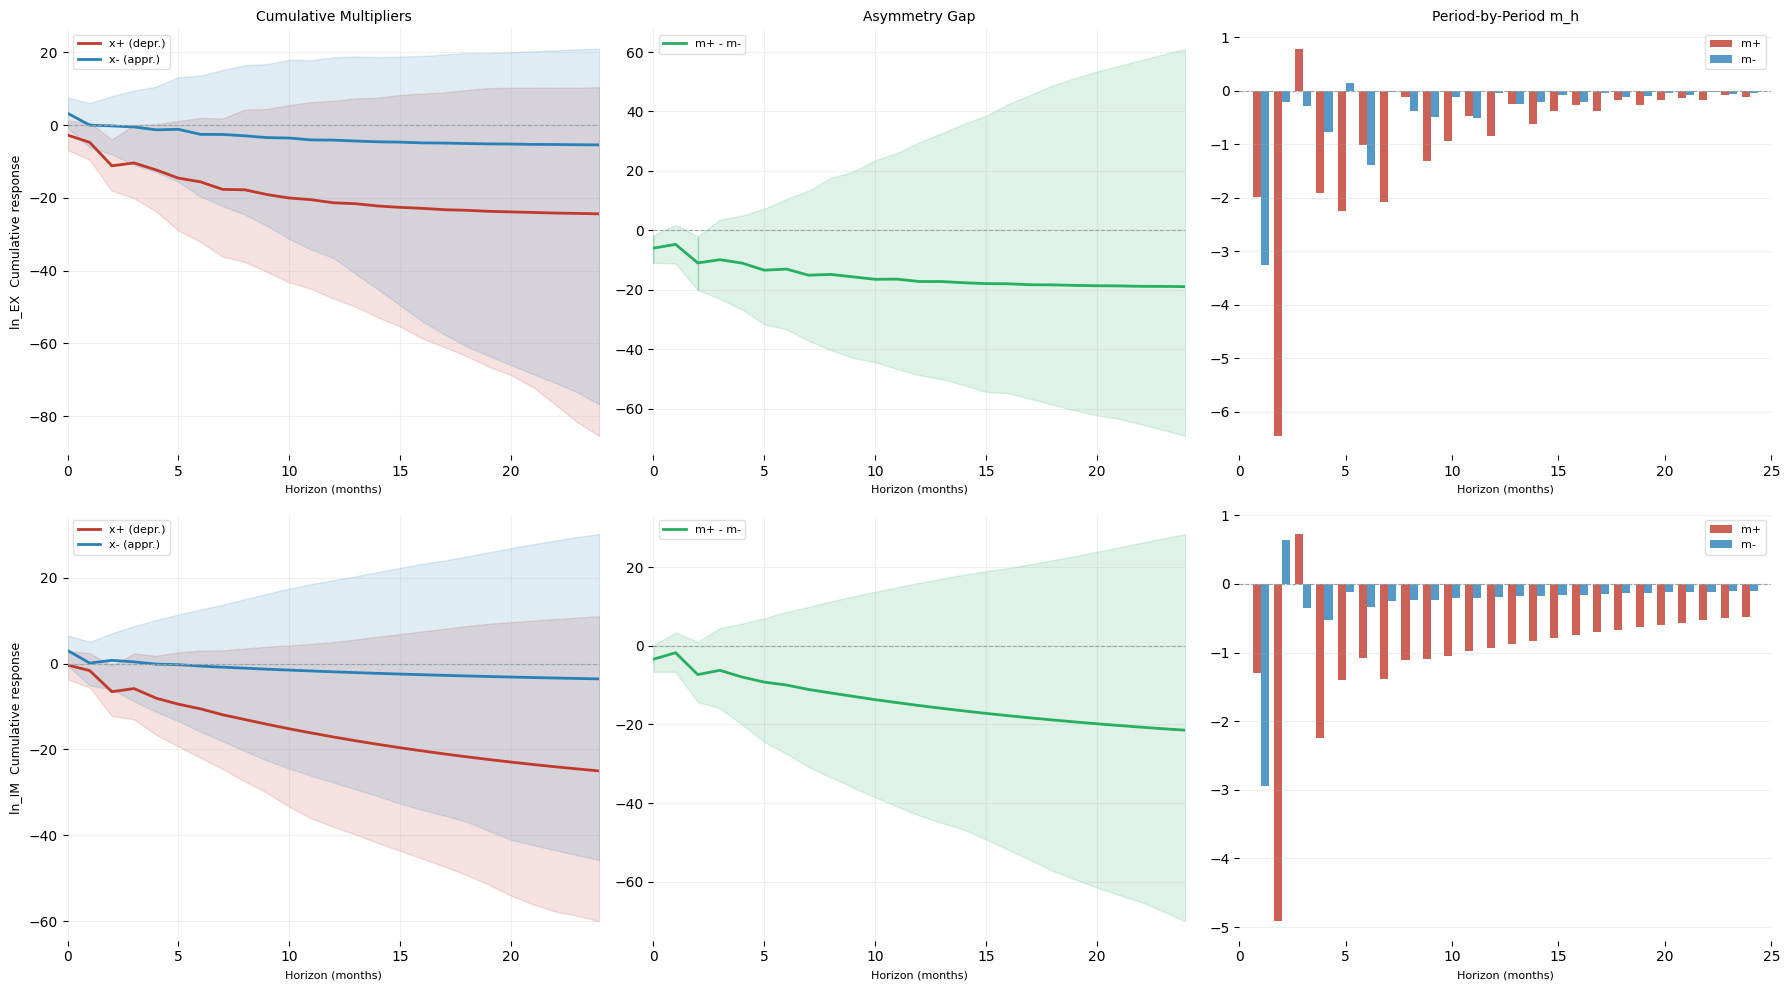

Saved -> ../results/dynamic_multiplier\dynamic_multiplier_combined.png


In [9]:
# Sau khi tạo fig, axes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Bỏ khung xung quanh tất cả axes
for ax_row in axes:
    for ax in ax_row:
        # Ẩn tất cả các spines
        for spine in ax.spines.values():
            spine.set_visible(False)
        # Hoặc nếu muốn chỉ ẩn top và right:
        # ax.spines['top'].set_visible(False)
        # ax.spines['right'].set_visible(False)

# Tiếp tục phần vẽ như trước
for row_i, (model_name, dm) in enumerate(dm_results.items()):
    dep = fitted_models[model_name]['dep']
    h   = dm['horizon']

    ax = axes[row_i, 0]
    ax.plot(h, dm['pos'], color=C_POS, lw=2, label='x+ (depr.)')
    ax.fill_between(h, dm['pos_lo'], dm['pos_hi'], color=C_POS, alpha=0.15)
    ax.plot(h, dm['neg'], color=C_NEG, lw=2, label='x- (appr.)')
    ax.fill_between(h, dm['neg_lo'], dm['neg_hi'], color=C_NEG, alpha=0.15)
    ax.axhline(0, color=C_ZERO, lw=0.8, ls='--')
    ax.set_ylabel(f'{dep}  Cumulative response', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.6); ax.grid(alpha=0.2); ax.set_xlim(0, H)
    if row_i == 0: ax.set_title('Cumulative Multipliers', fontsize=10)

    ax = axes[row_i, 1]
    ax.plot(h, dm['diff'], color=C_DIFF, lw=2, label='m+ - m-')
    ax.fill_between(h, dm['diff_lo'], dm['diff_hi'], color=C_DIFF, alpha=0.15)
    sig_mask = (dm['diff_lo'] > 0) | (dm['diff_hi'] < 0)
    if sig_mask.any():
        ax.fill_between(h, dm['diff_lo'], dm['diff_hi'],
                        where=sig_mask, color=C_DIFF, alpha=0.40)
    ax.axhline(0, color=C_ZERO, lw=0.8, ls='--')
    ax.legend(fontsize=8, framealpha=0.6); ax.grid(alpha=0.2); ax.set_xlim(0, H)
    if row_i == 0: ax.set_title('Asymmetry Gap', fontsize=10)

    ax = axes[row_i, 2]
    w = 0.38; x = h[1:]
    ax.bar(x - w/2, dm['m_pos'][1:], width=w, color=C_POS, alpha=0.8, label='m+')
    ax.bar(x + w/2, dm['m_neg'][1:], width=w, color=C_NEG, alpha=0.8, label='m-')
    ax.axhline(0, color=C_ZERO, lw=0.8, ls='--')
    ax.legend(fontsize=8, framealpha=0.6); ax.grid(axis='y', alpha=0.2); ax.set_xlim(0, H + 1)
    if row_i == 0: ax.set_title('Period-by-Period m_h', fontsize=10)

    for ax in axes[row_i]:
        ax.set_xlabel('Horizon (months)', fontsize=8)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'dynamic_multiplier_combined.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')  # đảm bảo nền trắng
plt.show()
print(f'Saved -> {path}')

## 5. Export Tables

In [7]:
for model_name, dm in dm_results.items():
    df_out = pd.DataFrame({
        'horizon'      : dm['horizon'],
        'cum_pos'      : dm['pos'],   'cum_pos_lo95': dm['pos_lo'],  'cum_pos_hi95': dm['pos_hi'],
        'cum_neg'      : dm['neg'],   'cum_neg_lo95': dm['neg_lo'],  'cum_neg_hi95': dm['neg_hi'],
        'asymmetry'    : dm['diff'],  'asym_lo95'   : dm['diff_lo'], 'asym_hi95'   : dm['diff_hi'],
        'period_m_pos' : dm['m_pos'], 'period_m_neg': dm['m_neg'],   'ar_irf_phi'  : dm['phi']
    })
    path = os.path.join(OUTPUT_DIR, f'multipliers_{model_name}.csv')
    df_out.to_csv(path, index=False); print(f'Saved {model_name} -> {path}')

# Key-horizon summary
rows = []
for model_name, dm in dm_results.items():
    dep = fitted_models[model_name]['dep']
    for h in [1, 3, 6, 12, 18, 24]:
        rows.append({
            'Model': model_name, 'Dep': dep, 'Horizon': h,
            'Cum_m+': round(dm['pos'][h], 4),  'CI+_lo': round(dm['pos_lo'][h], 4),  'CI+_hi': round(dm['pos_hi'][h], 4),
            'Cum_m-': round(dm['neg'][h], 4),  'CI-_lo': round(dm['neg_lo'][h], 4),  'CI-_hi': round(dm['neg_hi'][h], 4),
            'Asymmetry': round(dm['diff'][h], 4),
            'Asym_sig': 'Yes' if (dm['diff_lo'][h] > 0 or dm['diff_hi'][h] < 0) else 'No'
        })
df_sum = pd.DataFrame(rows)
path = os.path.join(OUTPUT_DIR, 'multipliers_summary.csv')
df_sum.to_csv(path, index=False)
print(f'Summary -> {path}')
print(df_sum.to_string(index=False))

Saved Model_2_EX -> ../results/dynamic_multiplier\multipliers_Model_2_EX.csv
Saved Model_3_IM -> ../results/dynamic_multiplier\multipliers_Model_3_IM.csv
Summary -> ../results/dynamic_multiplier\multipliers_summary.csv
     Model   Dep  Horizon   Cum_m+   CI+_lo  CI+_hi  Cum_m-   CI-_lo  CI-_hi  Asymmetry Asym_sig
Model_2_EX ln_EX        1  -4.7620  -9.5974  0.6218 -0.0332  -6.1755  6.0346    -4.7289       No
Model_2_EX ln_EX        3 -10.4288 -20.0925 -0.0003 -0.5391 -10.9640  9.4870    -9.8897       No
Model_2_EX ln_EX        6 -15.6194 -32.1429  1.9306 -2.5764 -19.6666 13.5506   -13.0430       No
Model_2_EX ln_EX       12 -21.3792 -47.7019  6.6709 -4.1528 -36.5356 18.6065   -17.2264       No
Model_2_EX ln_EX       18 -23.4411 -63.5033  9.6315 -5.0944 -60.8550 19.7891   -18.3466       No
Model_2_EX ln_EX       24 -24.4157 -85.4717 10.4092 -5.4617 -76.8218 20.9703   -18.9539       No
Model_3_IM ln_IM        1  -1.6376  -5.5916  2.4165  0.1107  -5.1250  5.0554    -1.7483       No
Model